# 미니프로젝트: 앙상블 모델링 (Vibe Coding)

#### <목표>
Day 3에서 배운 **Random Forest, GBM, XGBoost, LightGBM, CatBoost**를 Day 2와 **동일한 제조 데이터셋**에 적용해 봅니다.

- Day 1에서의 EDA, 전처리를 복습해보고
- Day 2에서 배웠던 다중선형회귀·Ridge·Lasso·의사결정나무로 만든 결과와 비교하면서
- Day 3에서 배운 앙상블 모델이 단일 모델 대비 어떤 성능 차이를 보이는지 확인해봅니다.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (회귀) |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (분류) |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

**[과제]** 써니는 Day 2에서 사용한 회귀 및 분류 데이터셋에 다양한 트리 기반 앙상블 모델을 적용해 보려고 합니다. 분석 준비와 데이터 전처리뿐만 아니라, 앙상블 모델 구축 및 하이퍼파라미터 탐색에 필요한 라이브러리를 AI와 상의하여 선정하고 불러오는 코드를 작성해 보세요.

In [29]:
# 기본
import os
import warnings
import time
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 분할 / 하이퍼파라미터 탐색
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,      # 선택: 교차검증 비교 시
)

# 전처리 (Day 2와 동일 — 트리 모델은 필수는 아니지만 비교·실습용)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Day 2 모델 (성능·변수 중요도 비교용)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

# Day 3 앙상블 — Random Forest
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingRegressor,
)

# Day 3 앙상블 — XGBoost / LightGBM / CatBoost
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# 회귀 성능 지표
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# 분류 성능 지표
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# 경고 숨김 / 그래프 크기
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)

from sklearn.model_selection import (
    train_test_split,   # train/valid 분리 (튜닝 전)
    GridSearchCV,         # 그리드 탐색 — 과제에서 명시
)

from sklearn.model_selection import (
    cross_val_score,        # 튜닝 전/후 CV 점수 빠르게 확인
    RandomizedSearchCV,     # 조합이 많을 때 무작위 샘플링 탐색
    KFold,                  # 일반 교차검증
    StratifiedKFold,        # 분류 — 클래스 비율 유지 CV
    TimeSeriesSplit,        # 회귀(시계열) — 시간 순서 유지 CV
)

from sklearn.model_selection import TimeSeriesSplitㅠ

ImportError: cannot import name 'TimeSeriesSplitᅲ' from 'sklearn.model_selection' (/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/model_selection/__init__.py)

In [ ]:
#한글폰트
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "AppleGothic"   # macOS 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False     # 마이너스 기호 깨짐 방지

---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_reg.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [ ]:
df_reg = pd.read_csv("/Users/user/Desktop/cursor 연습/9일차/dataset/day2_miniproject_reg.csv")

---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [ ]:
target = "% Silica Concentrate"

# 1) 구조
print("=== 데이터 크기 ===")
print(df_reg.shape)

print("\n=== 변수명 ===")
print(df_reg.columns.tolist())

print("\n=== 데이터 타입 ===")
print(df_reg.dtypes)

print("\n=== 기본 통계량 ===")
display(df_reg.describe())

df_reg.info()

# 2) 결측치
print("\n=== 결측치 개수 ===")
print(df_reg.isnull().sum())

print("\n=== 결측치 비율(%) ===")
print((df_reg.isnull().mean() * 100).round(2))

print("\n=== 중복 행 ===")
print(df_reg.duplicated().sum())

# 3) 수집 기간
df_reg["date"] = pd.to_datetime(df_reg["date"])
print("\n=== 수집 기간 ===")
print("시작:", df_reg["date"].min())
print("종료:", df_reg["date"].max())
print("총 일수:", (df_reg["date"].max() - df_reg["date"].min()).days, "일")
print("고유 시점 수:", df_reg["date"].nunique())
print("측정 간격:", df_reg.sort_values("date")["date"].diff().mode().iloc[0])

=== 데이터 크기 ===
(3948, 24)

=== 변수명 ===
['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate', '% Silica Concentrate']

=== 데이터 타입 ===
date                             object
% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     float64
Amina Flow                      float64
Ore Pulp Flow                   float64
Ore Pulp pH                     float64
Ore Pulp Density                float64
Flotation Column 01 Air Flow  

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,...,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000,3948.000000
mean,56.220301,14.767789,2847.012956,488.720690,397.471417,9.769643,1.679042,281.287417,278.182019,282.253076,...,292.293595,520.425277,523.195899,532.182319,418.095661,422.776652,426.996977,418.128753,65.027176,2.322261
std,5.231150,6.887711,948.913479,83.769854,8.491449,0.378012,0.063417,29.361843,29.490104,28.244196,...,26.527575,123.756672,116.664614,140.549112,76.142141,74.612107,74.714161,71.636366,1.109367,1.120117
min,42.740000,1.310000,54.595483,242.927477,376.837604,8.753389,1.519926,175.885579,178.188430,177.202665,...,199.728122,181.925623,224.909663,135.214506,165.725058,214.735894,203.702926,185.061388,62.050000,0.600000
25%,52.610000,8.812500,2146.232398,436.428747,398.774394,9.542790,1.649868,250.109688,250.119040,250.109164,...,299.031694,409.067986,449.187215,402.250428,351.264361,350.829644,353.171861,350.734692,64.350000,1.440000
50%,55.940000,14.200000,2880.359057,502.685958,399.835435,9.796511,1.694900,299.850578,299.596767,299.893233,...,299.876333,499.582128,499.840739,499.584794,400.834364,400.626158,402.707483,400.495361,65.190000,2.000000
75%,59.720000,20.140000,3514.789671,550.144572,400.592916,10.033416,1.719869,299.955660,299.991808,299.948658,...,300.129489,599.849921,599.424594,600.303602,494.603949,497.296990,489.623260,454.574938,65.830000,2.992500
max,65.780000,33.400000,6270.158798,736.982378,418.070232,10.807370,1.818191,312.295415,309.887767,302.783000,...,351.268656,859.025062,827.775874,884.840698,675.631942,674.068176,698.505832,655.501603,68.010000,5.530000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          3948 non-null   object 
 1   % Iron Feed                   3948 non-null   float64
 2   % Silica Feed                 3948 non-null   float64
 3   Starch Flow                   3948 non-null   float64
 4   Amina Flow                    3948 non-null   float64
 5   Ore Pulp Flow                 3948 non-null   float64
 6   Ore Pulp pH                   3948 non-null   float64
 7   Ore Pulp Density              3948 non-null   float64
 8   Flotation Column 01 Air Flow  3948 non-null   float64
 9   Flotation Column 02 Air Flow  3948 non-null   float64
 10  Flotation Column 03 Air Flow  3948 non-null   float64
 11  Flotation Column 04 Air Flow  3948 non-null   float64
 12  Flotation Column 05 Air Flow  3948 non-null   float64
 13  Flo

### A-1-2) Graph 기반 탐색

**[과제]** 써니는 오늘도 어제처럼 시계열 변화 패턴과 변수 간 상관관계를 앙상블 모델링 전에 다시 시각화로 점검하려고 합니다. AI와 함께 시간 흐름에 따른 변수 변화를 시각화해 보세요.

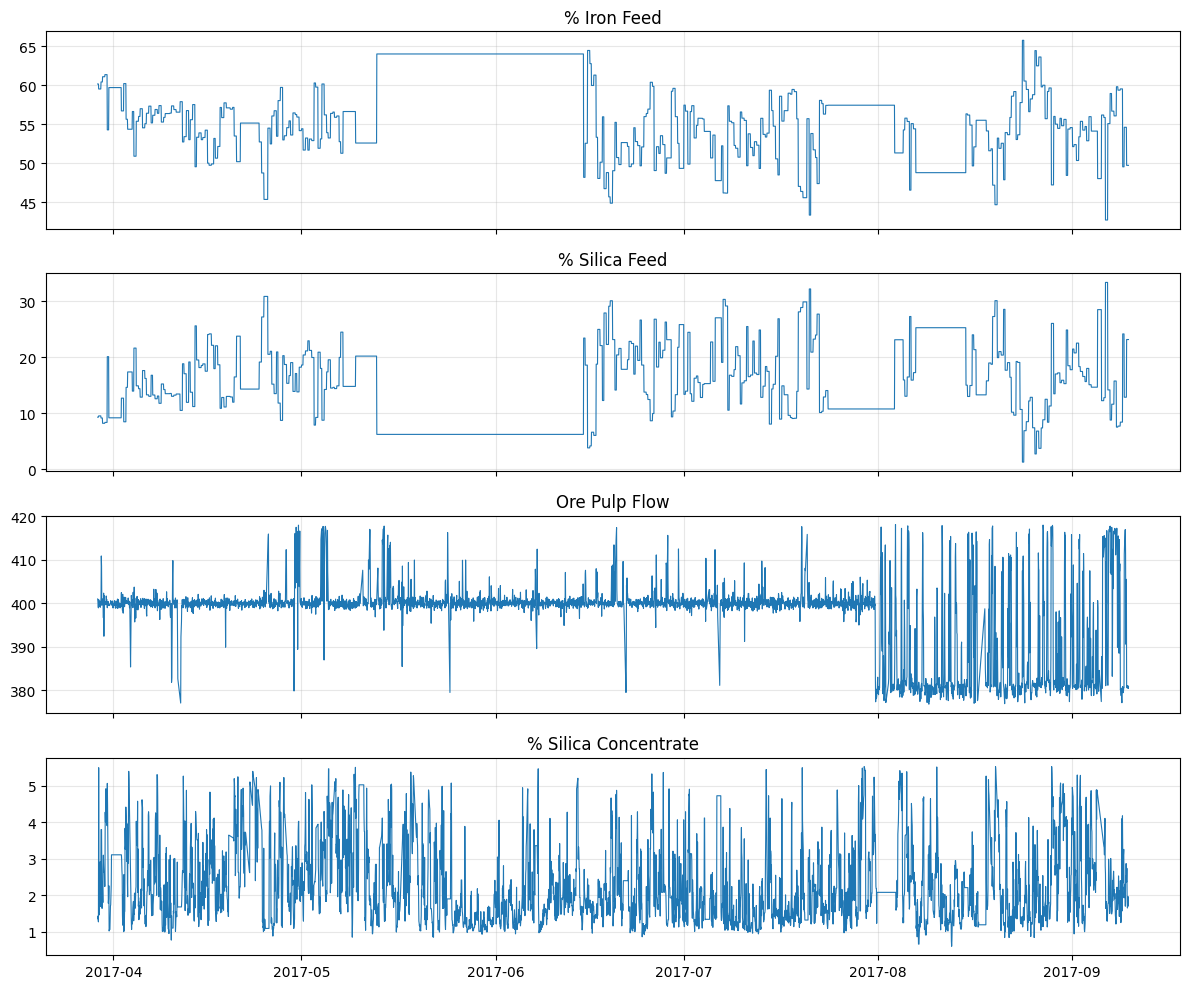

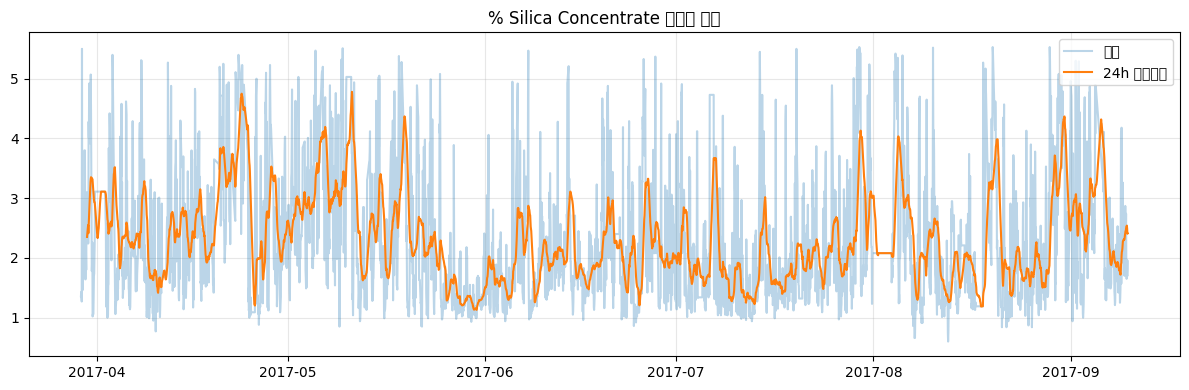

In [ ]:
# 준비
df_ts = df_reg.copy()
df_ts["date"] = pd.to_datetime(df_ts["date"])
df_ts = df_ts.sort_values("date")

target = "% Silica Concentrate"
cols = ["% Iron Feed", "% Silica Feed", "Ore Pulp Flow", target]

# 1) 주요 변수 시계열
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, col in zip(axes, cols):
    ax.plot(df_ts["date"], df_ts[col], linewidth=0.8)
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) 타겟 + 24시간 이동평균
plt.figure(figsize=(12, 4))
plt.plot(df_ts["date"], df_ts[target], alpha=0.3, label="원본")
plt.plot(df_ts["date"], df_ts[target].rolling(24).mean(), label="24h 이동평균")
plt.title(f"{target} 시간별 변화")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. AI와 상의해서 상관관계 히트맵을 그려보고 트리 기반 앙상블 모델에서는 이 다중공선성이 Day 2의 선형 모델만큼 문제가 되는지도 함께 생각해 보세요.

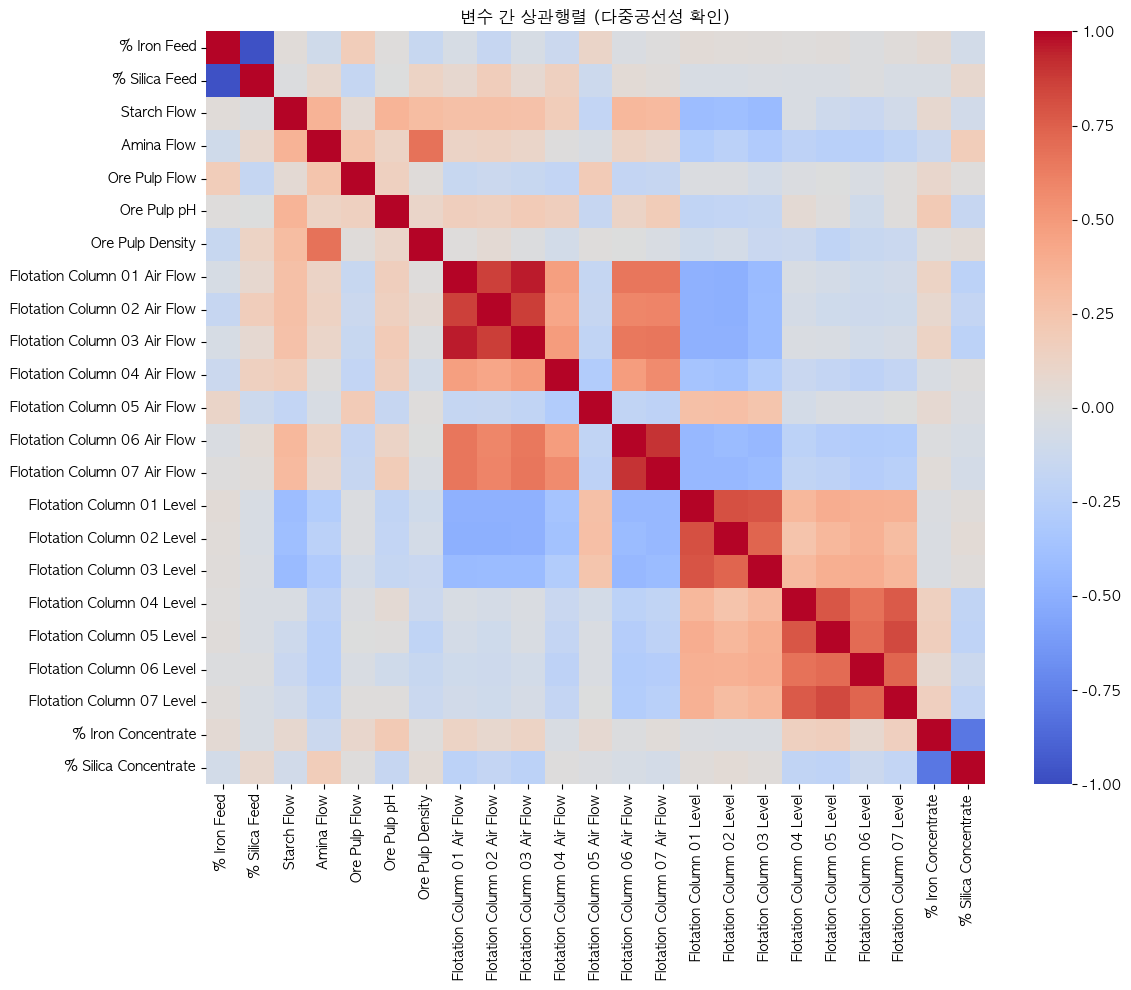

In [ ]:
target = "% Silica Concentrate"
num_cols = df_reg.select_dtypes(include="number").columns

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_reg[num_cols].corr(),
    cmap="coolwarm", center=0, vmin=-1, vmax=1
)
plt.title("변수 간 상관행렬 (다중공선성 확인)")
plt.tight_layout()
plt.show()

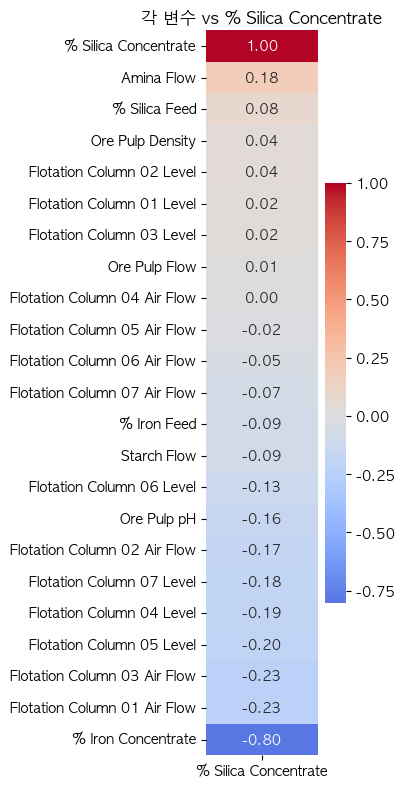

In [ ]:
plt.figure(figsize=(4, 8))
sns.heatmap(
    df_reg[num_cols].corr()[[target]].sort_values(target, ascending=False),
    annot=True, fmt=".2f", cmap="coolwarm", center=0
)
plt.title(f"각 변수 vs {target}")
plt.tight_layout()
plt.show()

---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 Heatmap을 통해 타겟변수와 강한 상관관계를 가지는 변수를 발견하였습니다. 해당 변수가 데이터 누수를 유발할 수 있는지가 궁금해졌습니다. AI와 함께 상의하여 해당 변수 제거 여부를 검토하고 결정해보세요.

In [ ]:
target = "% Silica Concentrate"

# 제거: date(입력 아님), % Iron Concentrate(결과 변수 → 누수)
drop_cols = ["date", "% Iron Concentrate"]

df_reg["date"] = pd.to_datetime(df_reg["date"])

X_reg = df_reg.drop(columns=drop_cols + [target])
y_reg = df_reg[target]

print("제거:", drop_cols)
print("입력 변수 수:", X_reg.shape[1])
print("타겟:", target)

제거: ['date', '% Iron Concentrate']
입력 변수 수: 21
타겟: % Silica Concentrate


In [ ]:
# 제거 전: 타겟과 가장 강한 상관
before = df_reg.corr(numeric_only=True)[target].drop(target).abs().idxmax()
print("제거 전 최대 상관 변수:", before)

# 제거 후: Iron Concentrate 없어졌는지
print(X_reg.columns.tolist())

제거 전 최대 상관 변수: % Iron Concentrate
['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level']


### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하려고 합니다. Day 2와 마찬가지로 시계열 데이터라는 점을 고려하여 데이터를 분할해보세요.

In [ ]:
target = "% Silica Concentrate"
drop_cols = ["date", "% Iron Concentrate"]

# 1) date 변환 + 시간 순 정렬
df_reg["date"] = pd.to_datetime(df_reg["date"])
df = df_reg.sort_values("date").reset_index(drop=True)

# 2) X, y 분리
Y = df[target]
X = df.drop(columns=drop_cols + [target])

# 3) 시계열 분할 (70 : 30)
split_idx = int(len(df) * 0.7)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
Y_train = Y.iloc[:split_idx]
Y_test  = Y.iloc[split_idx:]

print("train:", X_train.shape, "test:", X_test.shape)
print("train 기간:", df["date"].iloc[0], "~", df["date"].iloc[split_idx - 1])
print("test  기간:", df["date"].iloc[split_idx], "~", df["date"].iloc[-1])

train: (2763, 21) test: (1185, 21)
train 기간: 2017-03-29 12:00:00 ~ 2017-07-22 14:00:00
test  기간: 2017-07-22 15:00:00 ~ 2017-09-09 23:00:00


### A-2-3) 스케일링 필요 여부 검토

**[과제]** 써니는 Day 2에서는 Ridge/Lasso 모델 특성 때문에 StandardScaler를 적용했었는데 Day 3에서 사용할 Random Forest·GBM·XGBoost·LightGBM·CatBoost도 스케일링이 꼭 필요한지 AI와 상의해서 판단해 보세요.

In [ ]:
# 트리 기반 앙상블 → 스케일링 불필요
# X_train, X_test 원본 그대로 사용

RF = RandomForestRegressor(random_state=0)
RF.fit(X_train, Y_train)
pred = RF.predict(X_test)

---
## A-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 선형 모델용 스케일링 (Day2와 동일)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alpha = 1.0

# (모델명, 모델, train X, test X)
models = [
    ("Linear",        LinearRegression(), X_train_scaled, X_test_scaled),
    ("Ridge",           Ridge(alpha=alpha), X_train_scaled, X_test_scaled),
    ("Lasso",           Lasso(alpha=alpha, max_iter=10000), X_train_scaled, X_test_scaled),
    ("Decision Tree",   DecisionTreeRegressor(max_depth=5, random_state=0), X_train, X_test),
    ("RandomForest",    RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0, n_jobs=-1), X_train, X_test),
    ("GBM",             GradientBoostingRegressor(random_state=0), X_train, X_test),
    ("XGBoost",         XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=0, n_jobs=-1), X_train, X_test),
    ("LightGBM",        LGBMRegressor(n_estimators=100, random_state=0, verbose=-1, n_jobs=-1), X_train, X_test),
    ("CatBoost",        CatBoostRegressor(n_estimators=100, random_state=0, verbose=0), X_train, X_test),
]

results = []
pred_dict = {}

for name, model, Xtr, Xte in models:
    model.fit(Xtr, Y_train)
    pred = model.predict(Xte)
    pred_dict[name] = pred

    results.append({
        "Model": name,
        "Group": "Day2" if name in ["Linear", "Ridge", "Lasso", "Decision Tree"] else "Day3",
        "RMSE": np.sqrt(mean_squared_error(Y_test, pred)),
        "MAE":  mean_absolute_error(Y_test, pred),
        "R2":   r2_score(Y_test, pred),
    })

compare_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
compare_df

,Model,Group,RMSE,MAE,R2
0,GBM,Day3,1.057149,0.824811,0.131560
1,RandomForest,Day3,1.072971,0.849715,0.105370
2,Decision Tree,Day2,1.098554,0.828548,0.062201
3,LightGBM,Day3,1.099699,0.836320,0.060245
4,XGBoost,Day3,1.110179,0.880847,0.042248
5,Lasso,Day2,1.135522,0.900161,-0.001978
6,CatBoost,Day3,1.158338,0.913333,-0.042647
7,Ridge,Day2,1.201807,0.903589,-0.122372
8,Linear,Day2,1.203477,0.904676,-0.125494


=== 회귀 모델 성능 비교 (RMSE 낮을수록 좋음) ===


,Model,Group,RMSE,MAE,R2
0,GBM,Day3,1.0571,0.8248,0.1316
1,RandomForest,Day3,1.0730,0.8497,0.1054
2,Decision Tree,Day2,1.0986,0.8285,0.0622
3,LightGBM,Day3,1.0997,0.8363,0.0602
4,XGBoost,Day3,1.1102,0.8808,0.0422
5,Lasso,Day2,1.1355,0.9002,-0.0020
6,CatBoost,Day3,1.1583,0.9133,-0.0426
7,Ridge,Day2,1.2018,0.9036,-0.1224
8,Linear,Day2,1.2035,0.9047,-0.1255


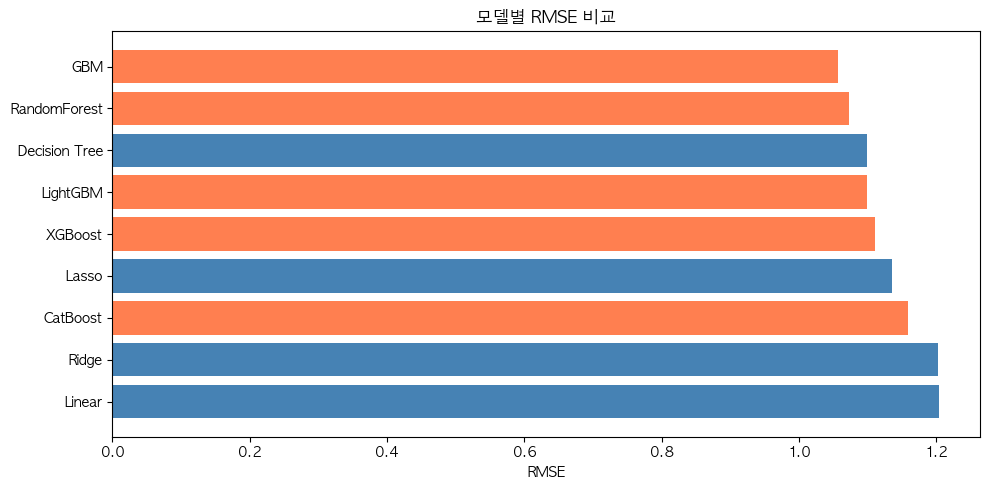

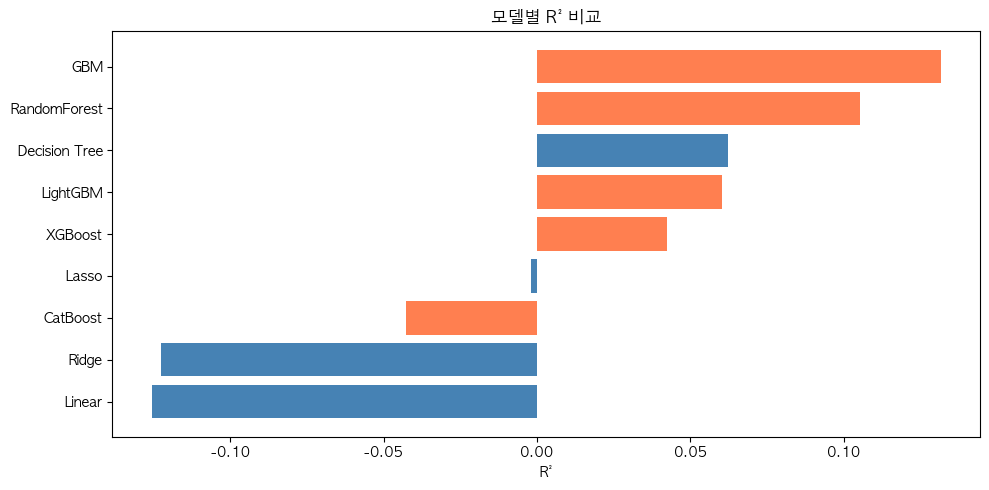

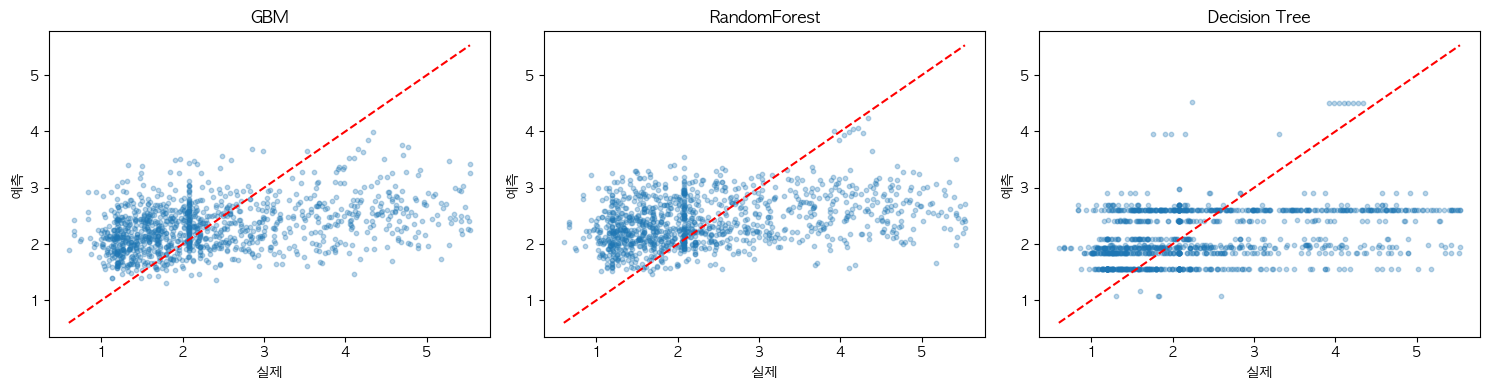

In [ ]:
# 표
print("=== 회귀 모델 성능 비교 (RMSE 낮을수록 좋음) ===")
display(compare_df.round(4))

# RMSE 막대그래프
plt.figure(figsize=(10, 5))
colors = compare_df["Group"].map({"Day2": "steelblue", "Day3": "coral"})
plt.barh(compare_df["Model"], compare_df["RMSE"], color=colors)
plt.xlabel("RMSE")
plt.title("모델별 RMSE 비교")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# R² 막대그래프
plt.figure(figsize=(10, 5))
plt.barh(compare_df["Model"], compare_df["R2"], color=colors)
plt.xlabel("R²")
plt.title("모델별 R² 비교")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 실제 vs 예측 (상위 3개 모델)
top3 = compare_df.head(3)["Model"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, top3):
    ax.scatter(Y_test, pred_dict[name], alpha=0.3, s=10)
    ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "r--")
    ax.set_title(name)
    ax.set_xlabel("실제")
    ax.set_ylabel("예측")
plt.tight_layout()
plt.show()

---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 Day 2에서 학습한 회귀 모델들과 Day 3에서 학습한 앙상블 모델들이 중요하다고 판단하는 공정 변수가 모델에 따라 얼마나 일관되게 나타나는지 궁금해졌습니다. AI와 함께 변수 중요도 및 회귀 계수를 비교할 수 있는 코드를 작성하고 여러 모델에서 공통적으로 중요하게 선정되는 핵심 공정 변수가 무엇인지 분석해 보세요.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def norm_imp(x):
    x = np.abs(x)
    return x / x.max() if x.max() > 0 else x

# A-3에서 fit된 모델 dict 만들기
fitted = {name: model for name, model, _, _ in models}

# ── (1) 회귀 계수: Linear, Ridge, Lasso ──
linear_names = ["Linear", "Ridge", "Lasso"]

coef_df = pd.DataFrame({"Variable": X_train.columns})
for name in linear_names:
    coef_df[name] = fitted[name].coef_

coef_df["|Ridge|"] = coef_df["Ridge"].abs()

print("=== 회귀 계수 Top 10 (|Ridge| 기준) ===")
display(coef_df.sort_values("|Ridge|", ascending=False).head(10))

# ── (2) 변수 중요도: Decision Tree + Day3 앙상블 5종 ──
tree_names = ["Decision Tree", "RandomForest", "GBM", "XGBoost", "LightGBM", "CatBoost"]

imp_df = pd.DataFrame({"Variable": X_train.columns})
imp_df["Linear(Ridge|coef|)"] = norm_imp(fitted["Ridge"].coef_)

for name in tree_names:
    imp_df[name] = fitted[name].feature_importances_

# ── (3) 전 모델 평균 ──
all_cols = ["Linear(Ridge|coef|)"] + tree_names
imp_df["Average"] = imp_df[all_cols].mean(axis=1)
imp_df = imp_df.sort_values("Average", ascending=False)

print("\n=== 변수 중요도 통합 Top 10 ===")
display(imp_df[["Variable"] + all_cols + ["Average"]].head(10))

=== 회귀 계수 Top 10 (|Ridge| 기준) ===


,Variable,Linear,Ridge,Lasso,|Ridge|
1,% Silica Feed,0.345704,0.339428,0.0,0.339428
0,% Iron Feed,0.304515,0.297906,-0.0,0.297906
3,Amina Flow,0.298111,0.297666,0.0,0.297666
10,Flotation Column 04 Air Flow,0.271379,0.270930,0.0,0.270930
9,Flotation Column 03 Air Flow,-0.269015,-0.266994,-0.0,0.266994
7,Flotation Column 01 Air Flow,-0.250680,-0.251185,-0.0,0.251185
12,Flotation Column 06 Air Flow,-0.245870,-0.243132,-0.0,0.243132
13,Flotation Column 07 Air Flow,0.186287,0.184226,-0.0,0.184226
18,Flotation Column 05 Level,-0.156506,-0.156619,-0.0,0.156619
6,Ore Pulp Density,-0.145182,-0.145014,0.0,0.145014



=== 변수 중요도 통합 Top 10 ===


,Variable,Linear(Ridge|coef|),Decision Tree,RandomForest,GBM,XGBoost,LightGBM,CatBoost,Average
3,Amina Flow,0.876963,0.094026,0.083773,0.090567,0.053593,197,8.217551,29.488068
5,Ore Pulp pH,0.230472,0.000000,0.045977,0.035969,0.034339,188,3.617613,27.423481
1,% Silica Feed,1.000000,0.098506,0.053344,0.082064,0.079648,170,7.224269,25.505404
19,Flotation Column 06 Level,0.154388,0.012572,0.049318,0.035604,0.041407,173,5.112778,25.486581
0,% Iron Feed,0.877671,0.005970,0.035099,0.057466,0.030892,167,6.801046,24.972592
7,Flotation Column 01 Air Flow,0.740027,0.055877,0.074627,0.074819,0.040847,158,5.795694,23.540270
4,Ore Pulp Flow,0.012319,0.000000,0.033094,0.016512,0.023054,160,2.904956,23.284276
6,Ore Pulp Density,0.427231,0.039910,0.041083,0.033728,0.038767,157,4.498957,23.154239
13,Flotation Column 07 Air Flow,0.542754,0.010146,0.021478,0.009672,0.026279,153,2.301619,22.273135
2,Starch Flow,0.359425,0.050867,0.044203,0.032978,0.028108,148,5.360503,21.982298


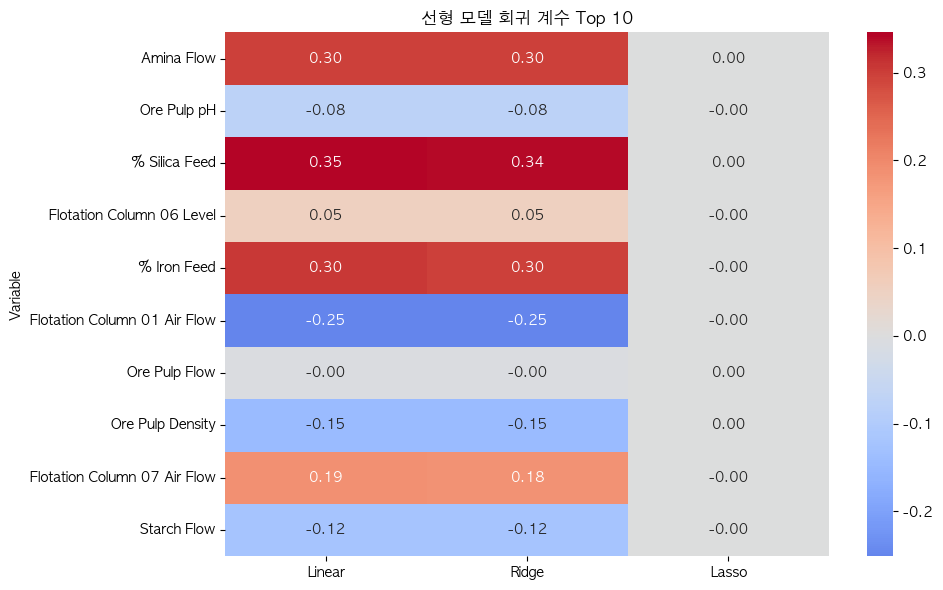

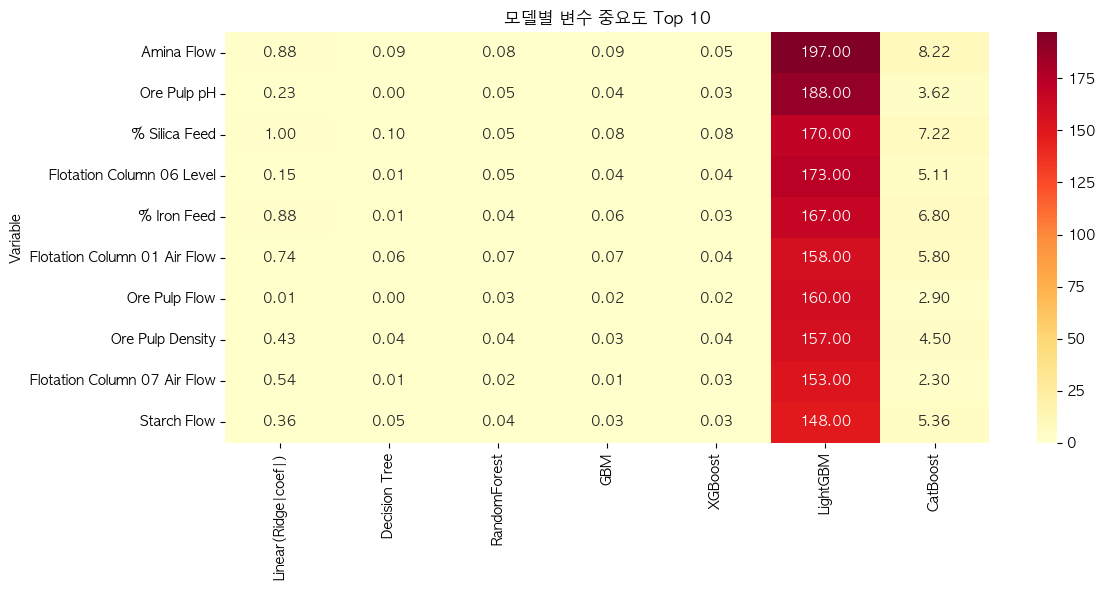

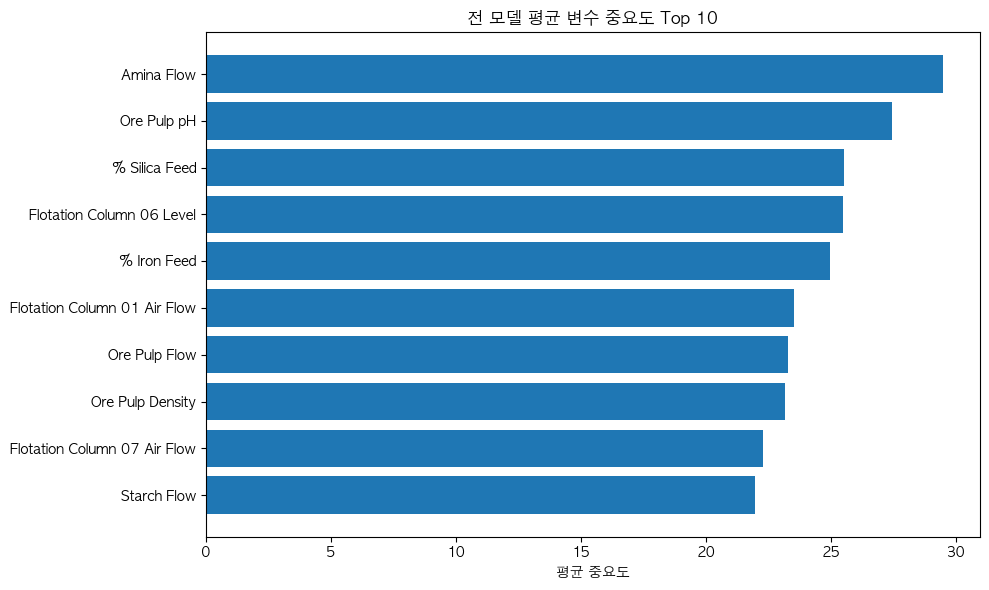

In [ ]:
top10 = imp_df.head(10)

# 회귀 계수 비교 (선형 3종)
plt.figure(figsize=(10, 6))
top_coef = coef_df.set_index("Variable")[linear_names].loc[top10["Variable"]]
sns.heatmap(top_coef, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("선형 모델 회귀 계수 Top 10")
plt.tight_layout()
plt.show()

# 변수 중요도 히트맵
plt.figure(figsize=(12, 6))
sns.heatmap(top10.set_index("Variable")[all_cols], annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("모델별 변수 중요도 Top 10")
plt.tight_layout()
plt.show()

# 평균 중요도
plt.figure(figsize=(10, 6))
plt.barh(top10["Variable"], top10["Average"])
plt.xlabel("평균 중요도")
plt.title("전 모델 평균 변수 중요도 Top 10")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**[과제]** 써니는 가장 우수했던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 논의하고 GridSearchCV로 최적의 조합을 찾아 성능을 개선해 보세요.

---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_cls.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [32]:
df_cla = pd.read_csv("/Users/user/Desktop/cursor 연습/9일차/dataset/day2_miniproject_cls.csv")

---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [33]:
# ============================================================
# B-1) df_cla 기본 특성 확인 (Value 기반 탐색)
# ============================================================

# 1) 데이터 구조
print("=== 데이터 크기 ===")
print(df_cla.shape)   # (행 수, 열 수)

print("\n=== 변수명 ===")
print(df_cla.columns.tolist())

print("\n=== 데이터 타입 ===")
print(df_cla.dtypes)

print("\n=== 상위 5행 ===")
display(df_cla.head())

print("\n=== 기본 통계량 (수치형) ===")
display(df_cla.describe())

print("\n=== info() ===")
df_cla.info()

=== 데이터 크기 ===
(1941, 34)

=== 변수명 ===
['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

=== 데이터 타입 ===
X_Minimum                  int64
X_Maximum                  int64
Y_Minimum                  int64
Y_Maximum                  int64
Pixels_Areas               int64
X_Perimeter                int64
Y_Perimeter                int64
Sum_of_Luminosity          int64
Minimum_of_Luminosity      int64
Maximum_of_Luminosity      int64
Length_of_Conveyer         int64
TypeOfSteel_A300

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0



=== 기본 통계량 (수치형) ===


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



=== info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   f

In [34]:
# 2) 결측치 · 중복 · 고유값
print("=== 결측치 개수 ===")
print(df_cla.isnull().sum())

print("\n=== 결측치 비율(%) ===")
print((df_cla.isnull().mean() * 100).round(2))

print("\n=== 전체 결측치 수 ===")
print(df_cla.isnull().sum().sum())

print("\n=== 중복 행 ===")
print(df_cla.duplicated().sum())

print("\n=== 변수별 고유값 개수 ===")
print(df_cla.nunique().sort_values())

=== 결측치 개수 ===
X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
Pastry                   0
Z_Scratch                0
K_Scatch                 0
Stains                   0
Dirtiness                0
Bumps                    0
Other_Faults             0
dtype: int64

=== 결측치 비율(%) ===
X_Minimum                0.0
X_Maxi

In [35]:
# 3) 데이터 범위 / 수집 맥락 (날짜 컬럼 없음)
# ※ 이 데이터셋에는 date 컬럼이 없어 '수집 기간'은 직접 확인 불가
#    대신 설비·소재·타겟 관련 기본 특성을 점검합니다.

print("=== 데이터셋 개요 ===")
print(f"총 관측치(결함 건수): {len(df_cla):,}건")
print(f"총 변수 수: {df_cla.shape[1]}개")

print("\n=== 설비/소재 변수 ===")
for col in ["Length_of_Conveyer", "Steel_Plate_Thickness"]:
    print(f"\n[{col}]")
    print(df_cla[col].describe())
    print("고유값:", df_cla[col].nunique(), "→", sorted(df_cla[col].unique())[:10], "...")

print("\n=== 철강 타입 (One-Hot) ===")
print(df_cla[["TypeOfSteel_A300", "TypeOfSteel_A400"]].value_counts())

print("\n=== 타겟 변수 K_Scatch 분포 ===")
print(df_cla["K_Scatch"].value_counts())
print("\n비율(%):")
print((df_cla["K_Scatch"].value_counts(normalize=True) * 100).round(2))

=== 데이터셋 개요 ===
총 관측치(결함 건수): 1,941건
총 변수 수: 34개

=== 설비/소재 변수 ===

[Length_of_Conveyer]
count    1941.000000
mean     1459.160227
std       144.577823
min      1227.000000
25%      1358.000000
50%      1364.000000
75%      1650.000000
max      1794.000000
Name: Length_of_Conveyer, dtype: float64
고유값: 84 → [np.int64(1227), np.int64(1280), np.int64(1306), np.int64(1308), np.int64(1320), np.int64(1322), np.int64(1324), np.int64(1333), np.int64(1336), np.int64(1346)] ...

[Steel_Plate_Thickness]
count    1941.000000
mean       78.737764
std        55.086032
min        40.000000
25%        40.000000
50%        70.000000
75%        80.000000
max       300.000000
Name: Steel_Plate_Thickness, dtype: float64
고유값: 24 → [np.int64(40), np.int64(50), np.int64(60), np.int64(69), np.int64(70), np.int64(80), np.int64(85), np.int64(90), np.int64(100), np.int64(120)] ...

=== 철강 타입 (One-Hot) ===
TypeOfSteel_A300  TypeOfSteel_A400
0                 1                   1164
1                 0           

**[과제]** 써니는 Day 2에서도 확인했던 타겟 변수(K_Scatch)의 클래스 불균형을 앙상블 모델링 전에 다시 한번 점검하려고 합니다. AI와 함께 타겟 변수의 빈도와 비율을 시각화해 보세요.

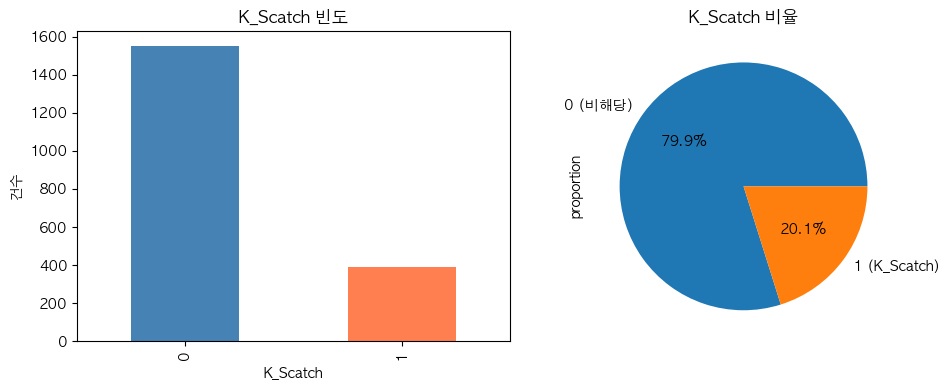

In [36]:
# 타겟 분포 시각화 (다음 과제용)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_cla["K_Scatch"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("K_Scatch 빈도")
axes[0].set_xlabel("K_Scatch")
axes[0].set_ylabel("건수")

(df_cla["K_Scatch"].value_counts(normalize=True) * 100).plot(
    kind="pie", ax=axes[1], autopct="%.1f%%", labels=["0 (비해당)", "1 (K_Scatch)"]
)
axes[1].set_title("K_Scatch 비율")
plt.tight_layout()
plt.show()

---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scatch를 분류 타겟(0/1)으로 사용하여 모델을 만들려고 합니다. 그런데 다른 결함 유형 변수들이 예측에 어떤 영향을 주는지 궁금해졌습니다. AI와 함께 각 결함 변수와 K_Scatch의 관계를 분석하고, 실제 공정 특성을 학습하기보다 정답을 미리 알려주는 역할을 하는 변수가 있는지 탐색해 보세요. 이후 이러한 변수들을 어떻게 처리하는 것이 적절할지 고민하고 적절한 전처리 방법을 적용해보세요.

In [37]:
fault_cols = ["Pastry", "Z_Scratch", "K_Scatch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]
other_fault_cols = [c for c in fault_cols if c != "K_Scatch"]
target = "K_Scatch"

# 교차표
for col in other_fault_cols:
    print(f"\n=== {col} vs {target} ===")
    display(pd.crosstab(df_cla[col], df_cla[target], margins=True))

# K_Scatch=1일 때 다른 결함 동시 발생 여부
ks1 = df_cla[df_cla[target] == 1]
print("\nK_Scatch=1일 때 다른 결함 보유:")
print((ks1[other_fault_cols].sum() == 0).all())  # True → 전부 0

# 행당 결함 라벨 개수
print("\n행당 결함 개수:")
print(df_cla[fault_cols].sum(axis=1).value_counts())


=== Pastry vs K_Scatch ===


K_Scatch,0,1,All
Pastry,,,
0,1392,391,1783
1,158,0,158
All,1550,391,1941



=== Z_Scratch vs K_Scatch ===


K_Scatch,0,1,All
Z_Scratch,,,
0,1360,391,1751
1,190,0,190
All,1550,391,1941



=== Stains vs K_Scatch ===


...


=== Bumps vs K_Scatch ===


K_Scatch,0,1,All
Bumps,,,
0,1148,391,1539
1,402,0,402
All,1550,391,1941



=== Other_Faults vs K_Scatch ===


K_Scatch,0,1,All
Other_Faults,,,
0,877,391,1268
1,673,0,673
All,1550,391,1941



K_Scatch=1일 때 다른 결함 보유:
True

행당 결함 개수:
1    1941
Name: count, dtype: int64


In [38]:
# 다른 결함이 하나라도 1 → K_Scatch=0
# 다른 결함이 전부 0   → K_Scatch=1
rule_pred = (df_cla[other_fault_cols].sum(axis=1) == 0).astype(int)
print((rule_pred == df_cla["K_Scatch"]).mean())  # 1.0

1.0


In [39]:
target = "K_Scatch"
leak_cols = ["Pastry", "Z_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

y = df_cla[target]
X = df_cla.drop(columns=[target] + leak_cols)

print(X.shape)   # (1941, 27)
print(y.value_counts(normalize=True).round(3))

(1941, 27)
K_Scatch
0    0.799
1    0.201
Name: proportion, dtype: float64


### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 데이터셋에 존재하는 클래스 불균형이 모델 학습과 평가에 영향을 줄 수 있다고 생각했습니다. AI와 함께 타겟 변수의 분포를 확인하고 원본 데이터의 클래스 비율이 학습 데이터와 테스트 데이터에도 유지될 수 있도록 적절한 데이터 분할 방법을 적용해 보세요.

In [40]:
from sklearn.model_selection import train_test_split

# B-2-1에서 정의한 변수 (누수 컬럼 제거 후)
target = "K_Scatch"
leak_cols = ["Pastry", "Z_Scratch", "Stains", "Dirtiness", "Bumps", "Other_Faults"]

y = df_cla[target]
X = df_cla.drop(columns=[target] + leak_cols)

# 계층적 분할 (클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0,
    stratify=y          # K_Scatch 0/1 비율을 train·test에 동일하게
)

print("학습:", X_train.shape, "| 테스트:", X_test.shape)
print("\n[전체]", y.value_counts(normalize=True).round(3).to_dict())
print("[학습]", y_train.value_counts(normalize=True).round(3).to_dict())
print("[테스트]", y_test.value_counts(normalize=True).round(3).to_dict())

학습: (1358, 27) | 테스트: (583, 27)

[전체] {0: 0.799, 1: 0.201}
[학습] {0: 0.798, 1: 0.202}
[테스트] {0: 0.799, 1: 0.201}


### B-2-3) 스케일링/인코딩 필요 여부 검토

**[과제]** 써니는 Day 2에서 로지스틱 회귀 모델 학습을 위해 스케일링을 적용했었습니다. 이번에 사용할 앙상블 모델들도 동일한 전처리가 필요한지 궁금해졌습니다. AI와 함께 모델별 특성을 살펴보고 스케일링과 인코딩이 필요한지 판단하여 적절한 전처리를 적용해 보세요.

---
## B-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

---
## B-5) 모델 결과 분석 및 고도화

**[과제]** 써니는 클래스 불균형이 성능에 영향을 줄 수 있다고 생각했습니다. 다만 모델마다 불균형을 다루는 방식이 다르다는 것을 알게 되었습니다. AI와 함께 각 모델에 맞는 불균형 완화 방법을 적용하고 적용 전후 성능을 비교해 보세요.

> 예:Random Forest는 `class_weight`, GBM은 `sample_weight`, XGBoost는 `scale_pos_weight`, LightGBM은 `is_unbalance`, CatBoost는 `auto_class_weights`

**[과제]** 써니는 불균형 완화까지 적용한 5개 모델의 변수 중요도를 비교해서, K_Scatch 결함 여부에 공통적으로 큰 영향을 주는 변수가 무엇인지 확인하려고 합니다. AI와 상의해서 비교 시각화를 만들어 보세요.

**[과제]** 써니는 불균형 완화 이후 F1-score가 가장 좋았던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 적절한 탐색 범위를 설정하여 GridSearchCV로 성능을 개선해 보세요.